1. Choix et importation de la base de données,  
    OASIS 1 seulement utiliser 3 catégorie (Mild Dementia, Non Demented, Very Mild Dementia) J'ai 10 patient par catégorie
    Par patient, j'ai pris 25 slice (80 à 104 sur fichier.hdr)
2. Exploration et prétraitement des données, 
    J'ai repris le travail qu'on avait regarde avec Madhi.

3. Extraction et représentation des caractéristiques, 
4. Sélection des caractéristiques ou réduction de dimension, 
5. Choix et étude de l’algorithme d’apprentissage supervisé, 
    SVM
6. Étude des hyperparamètres et des variantes de l’algorithme, 
7. Évaluation des performances selon différentes stratégies de validation, 
8. Analyse et interprétation des résultats, 
9. Bilan critique de l’algorithme étudié.

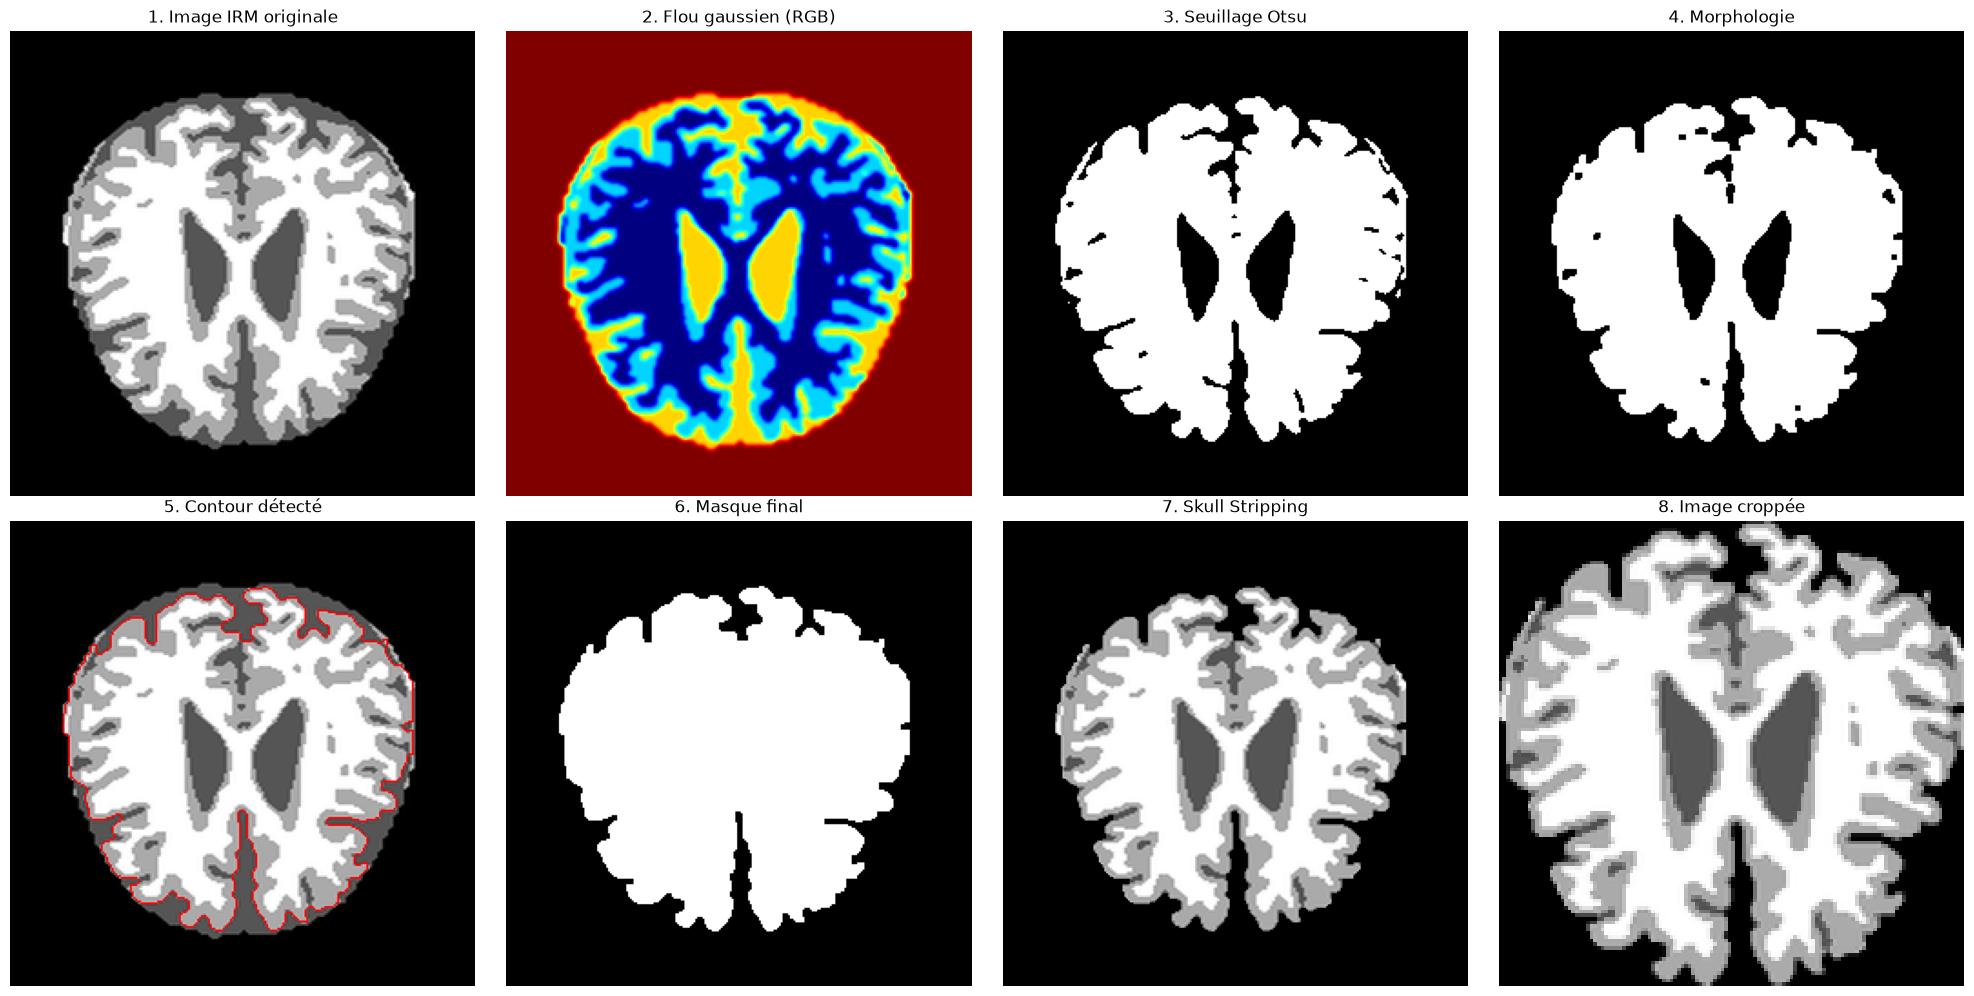

In [35]:
#2. Exploration et prétraitement des données,  Réutilisation de images IRM avec Mahdi Baccar
from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt

# === Chargement de l'image IRM ===
image_path = Path(
    "data/raw/Mild Demented/OAS1_0028_MR1_final/0028_nii_slice_025.png"
)
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
if img is None:
    raise ValueError("Image non trouvée.")

# === Étape 1 : Flou Gaussien ===
blurred = cv2.GaussianBlur(img, (5, 5), 0)

# === Étape 2 : Seuillage Otsu ===
_, thresh = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# === Étape 3 : Morphologie (nettoyage doux pour garder les détails) ===
kernel = np.ones((3, 3), np.uint8)
opened = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=1)
cleaned = cv2.morphologyEx(opened, cv2.MORPH_CLOSE, kernel, iterations=1)

# === Étape 4 : Détection des contours internes (pas juste le plus grand) ===
contours, _ = cv2.findContours(cleaned, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
mask = np.zeros_like(img)

# Conserver les contours situés vers le centre de l'image
for c in contours:
    M = cv2.moments(c)
    if M["m00"] == 0:
        continue
    cx = int(M["m10"] / M["m00"])
    cy = int(M["m01"] / M["m00"])
    if (img.shape[1]*0.15 < cx < img.shape[1]*0.85) and (img.shape[0]*0.15 < cy < img.shape[0]*0.85):
        cv2.drawContours(mask, [c], -1, 255, thickness=cv2.FILLED)

# === Étape 5 : Application du masque ===
brain_only = cv2.bitwise_and(img, mask)

# === Étape 6 : Cropping autour du cerveau ===
x, y, w, h = cv2.boundingRect(mask)
cropped_brain = brain_only[y:y+h, x:x+w]
cropped_resized = cv2.resize(cropped_brain, (128, 128))

# === VISUALISATION ===
blurred_rgb = cv2.applyColorMap(blurred, cv2.COLORMAP_JET)
contour_overlay = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
for c in contours:
    cv2.drawContours(contour_overlay, [c], -1, (255, 0, 0), 1)
mask_rgb = cv2.cvtColor(mask, cv2.COLOR_GRAY2BGR)

fig, axs = plt.subplots(2, 4, figsize=(20, 10))
steps = [
    (img, "1. Image IRM originale", 'gray'),
    (blurred_rgb, "2. Flou gaussien (RGB)", None),
    (thresh, "3. Seuillage Otsu", 'gray'),
    (cleaned, "4. Morphologie", 'gray'),
    (contour_overlay, "5. Contour détecté", None),
    (mask_rgb, "6. Masque final", None),
    (brain_only, "7. Skull Stripping", 'gray'),
    (cropped_resized, "8. Image croppée", 'gray'),
]

for ax, (image, title, cmap) in zip(axs.ravel(), steps):
    ax.imshow(image, cmap=cmap) if cmap else ax.imshow(image)
    ax.set_title(title)
    ax.axis('off')

plt.tight_layout()
plt.show()


In [36]:
#3. Extraction et représentation des caractéristiques, Les images se trouvent dans le dossier data/raw,
# LBP (Local Binary Patterns) est une méthode efficace pour extraire des caractéristiques de texture à partir d'images.

from skimage.feature import local_binary_pattern

input_dir = Path("data/raw")
output_dir = Path("data/treated")

# === Paramètres a modifier ici ===
P = 8 # nombre de point
R = 3 # rayon
METHOD = "ror"
"""
default: This is the original local binary pattern. It is grayscale invariant but not rotation invariant.

ror: This is an extension of the default pattern and is both grayscale and rotation invariant.

uniform: This method produces a uniform pattern that is both grayscale and rotation invariant. It offers finer quantization of the angular space, making it suitable for texture classification tasks.

nri_uniform: This is a variant of the uniform pattern that is grayscale invariant but not rotation invariant.

var: This method computes the variance of local image texture, which is related to contrast. It is rotation invariant but not grayscale invariant.
"""


image_extensions = {".png"}
all_histograms = []


def apply_lbp(image_path: Path, output_path: Path):
    # === Lecture en niveaux de gris ===
    image = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)

    if image is None:
        print(f"Image impossible à lire : {image_path}")
        return None

    # === Application du LBP ===
    lbp = local_binary_pattern(
        image,
        P=P,
        R=R,
        method=METHOD
    )

    # === Conversion pour sauvegarder l'image LBP ===
    lbp_image = np.clip(lbp, 0, 255).astype(np.uint8)

    # === Sauvegarde de l'image ===
    output_path.parent.mkdir(parents=True, exist_ok=True)
    cv2.imwrite(str(output_path), lbp_image)

    # === Calcul de l'histogramme ===
    histogram, _ = np.histogram(
        lbp.ravel(),
        bins=np.arange(257),
        range=(0, 256)
    )

    histogram = histogram.astype("float32")
    histogram /= histogram.sum() + 1e-7

    return histogram


# === Parcours récursif des images ===
for image_path in input_dir.rglob("*"):

    if image_path.is_file() and image_path.suffix.lower() in image_extensions:
        relative_path = image_path.relative_to(input_dir)
        output_path = output_dir / relative_path
        histogram = apply_lbp(image_path, output_path)

        # === Stockage de l'histogramme en mémoire et le path de l'image ===
        if histogram is not None:
            all_histograms.append({
                "image_path": str(relative_path),
                "histogram": histogram
            })

            # print(f"\nImage : {relative_path}")
            # print("Histogramme LBP :")
            # print(histogram)
            # print(f"Nombre de valeurs : {len(histogram)}")
            # print(f"Somme de l'histogramme : {histogram.sum():.4f}")


print("\nTraitement terminé.")
print(f"Nombre total d'histogrammes en RAM : {len(all_histograms)}")






Traitement terminé.
Nombre total d'histogrammes en RAM : 750


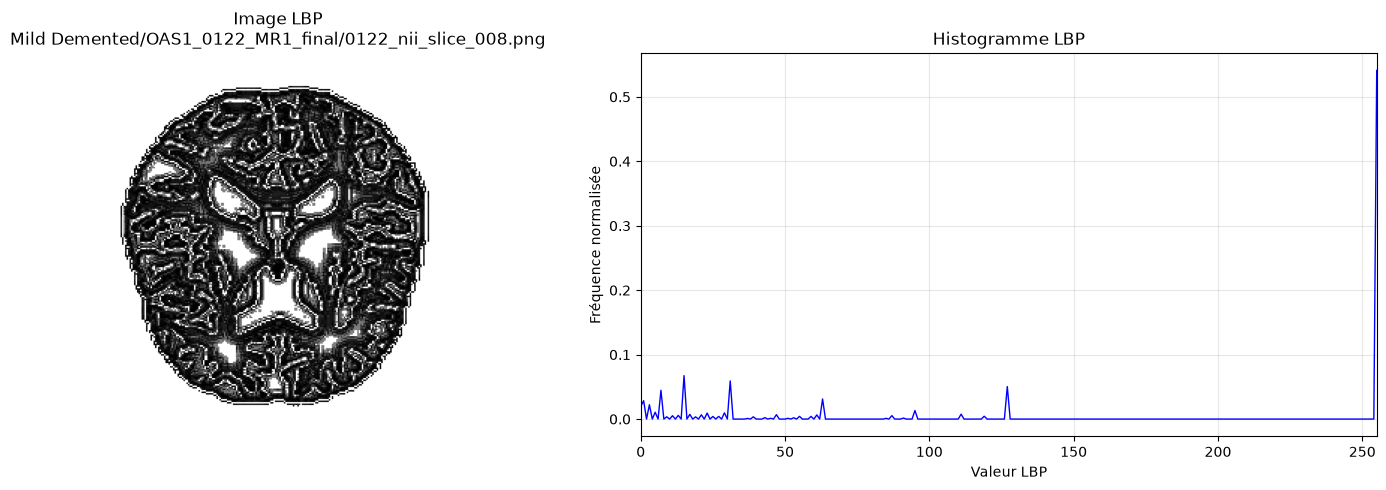

In [14]:
#3. Extraction et représentation des caractéristiques, Suite
# Exploration des histogrammes LBP et visualisation de la première image traitée

# === Récupération du premier histogramme et image traitée ===
X_ITEM = 250
premier_histogramme = all_histograms[X_ITEM]["histogram"]
premiere_image = all_histograms[X_ITEM]["image_path"]
premiere_image_path = output_dir / premiere_image


image_lbp = cv2.imread(
    str(premiere_image_path),
    cv2.IMREAD_GRAYSCALE
)
# === Affichage de l'image LBP et de l'histogramme ===
if image_lbp is None:
    print(f"Image impossible à lire : {premiere_image_path}")
else:
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    axes[0].imshow(image_lbp, cmap="gray")
    axes[0].set_title(f"Image LBP\n{premiere_image}")
    axes[0].axis("off")

    axes[1].plot(
        premier_histogramme,
        color="blue",
        linewidth=1
    )

    axes[1].set_title("Histogramme LBP")
    axes[1].set_xlabel("Valeur LBP")
    axes[1].set_ylabel("Fréquence normalisée")
    axes[1].set_xlim(0, 255)
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()





In [ ]:
# Separation des données en ensembles d'entraînement et de test

from sklearn.model_selection import train_test_split
import shutil

# === Séparation des données en ensembles d'entraînement et de test ===
data_dir = Path("data/treated")
extensions = {".png"}

images = []
labels = []

# === Séparation 80 % entraînement / 20 % test ===
for classe_dir in data_dir.iterdir():
    if classe_dir.is_dir():
        for image_path in classe_dir.rglob("*"):
            if image_path.suffix.lower() in extensions:
                images.append(image_path)
                labels.append(classe_dir.name)

X_train, X_test, y_train, y_test = train_test_split(
    images,
    labels,
    test_size=0.20,
    random_state=42,
    stratify=labels
)

train_dir = Path("data/split/train")
test_dir = Path("data/split/test")

for image_path, label in zip(X_train, y_train):
    destination = train_dir / label
    destination.mkdir(parents=True, exist_ok=True)
    shutil.copy2(image_path, destination / image_path.name)

for image_path, label in zip(X_test, y_test):
    destination = test_dir / label
    destination.mkdir(parents=True, exist_ok=True)
    shutil.copy2(image_path, destination / image_path.name)

print(f"Images d'entraînement : {len(X_train)}")
print(f"Images de test : {len(X_test)}")


Images d'entraînement : 600
Images de test : 150


In [28]:
from sklearn.preprocessing import OrdinalEncoder

# Conversion des labels en tableau  https://numpy.org/doc/stable/reference/generated/numpy.reshape.html
y_train_2d = np.array(y_train).reshape(-1, 1)
y_test_2d = np.array(y_test).reshape(-1, 1)

# Non Dementia       -> 0
# Very Mild Demented -> 1
# Mild Demented      -> 2
encoder = OrdinalEncoder(
    categories=[[
        "Non Dementia",
        "Very Mild Demented",
        "Mild Demented"
    ]]
)


# Apprentissage uniquement sur les données d'entraînement
y_train_encoded = encoder.fit_transform(y_train_2d)

# Application de la transformation sur les données de test
y_test_encoded = encoder.transform(y_test_2d)


# Conversion en vecteur 1D
y_train_encoded = y_train_encoded.ravel().astype(int)
y_test_encoded = y_test_encoded.ravel().astype(int)


print("Classes originales :", encoder.categories_)
print("y_train encodé :", y_train_encoded)
print("y_test encodé :", y_test_encoded)


Classes originales : [array(['Non Dementia', 'Very Mild Demented', 'Mild Demented'],
      dtype=object)]
y_train encodé : [0 2 1 2 2 2 1 0 2 2 1 0 2 2 2 1 1 1 0 1 1 0 1 0 2 0 0 1 0 1 1 0 1 0 0 0 1
 0 2 0 0 0 2 1 2 2 2 2 0 0 2 1 2 2 0 2 2 1 2 0 2 1 0 1 2 1 0 0 0 1 2 1 0 1
 0 2 0 2 2 1 1 1 0 1 1 1 0 0 2 0 0 0 1 0 1 1 2 2 0 0 1 0 2 2 0 0 1 2 0 1 1
 2 2 0 1 2 1 1 2 1 0 1 2 1 1 1 0 1 2 2 0 1 2 0 1 2 2 2 2 0 2 0 0 0 1 2 2 1
 2 1 1 0 1 0 1 2 2 2 2 1 1 0 0 2 2 0 2 2 2 2 2 2 0 0 1 0 1 1 0 2 1 2 0 1 0
 1 2 0 1 0 0 2 2 0 0 2 2 0 2 1 2 0 1 0 2 0 2 0 0 2 1 0 2 0 2 1 1 1 2 2 1 1
 2 0 2 0 1 1 1 0 0 2 0 2 1 0 1 1 0 0 0 2 0 0 0 2 2 2 1 2 1 1 0 2 1 2 0 0 0
 0 1 1 2 0 0 1 1 1 2 0 2 1 0 1 2 0 2 0 1 1 2 1 1 1 0 1 0 1 1 1 0 1 1 2 2 2
 1 2 2 0 1 2 0 0 1 1 0 2 2 0 1 1 2 0 0 0 0 0 0 0 0 2 0 0 1 2 2 0 1 1 1 0 0
 0 0 0 1 0 1 1 0 2 2 2 1 2 1 0 2 2 2 0 0 2 0 2 1 2 2 1 1 2 1 2 0 1 0 0 0 0
 1 1 2 1 0 0 2 2 2 1 1 2 1 1 1 0 0 1 0 2 1 2 2 0 0 0 2 0 2 1 1 0 0 1 2 2 2
 2 0 2 0 0 1 1 0 0 0 1 1 2 2 2 1 1 0 1 0 1 1 1 0 1 2

In [51]:
from sklearn.base import BaseEstimator, TransformerMixin
# https://scikit-learn.org/stable/modules/generated/sklearn.base.TransformerMixin.html
# === Transformation de chaque image en vecteur de pixels ===
class ImageToPixels(BaseEstimator, TransformerMixin):
    def __init__(self):
        pass

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        images = []

        for image_path in X:
            image = cv2.imread(
                str(image_path),
                cv2.IMREAD_GRAYSCALE
            )

            if image is None:
                raise ValueError(
                    f"Impossible de lire l'image : {image_path}"
                )

            image_array = image.astype(np.float32) / 255.0
            image_vector = image_array.flatten()
            images.append(image_vector)

        return np.asarray(images, dtype=np.float32)


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score


# TODO: faire un svm_pipeline avec un scaler et un SVC, puis entraîner le modèle sur les données d'entraînement et évaluer sur les données de test.

# Pipeline SVM  https://scikit-learn.org/stable/modules/svm.html
svm_pipeline = Pipeline([
    ("image_to_pixels", ImageToPixels()),
    ("scaler", StandardScaler()),
    ("svm", SVC(
        kernel="rbf",
        C=10,
        gamma="scale",
        random_state=42
    ))
])



# Entraînement uniquement sur les données train
svm_pipeline.fit(
    X_train,
    y_train
)


# Prédiction sur les données test
y_pred = svm_pipeline.predict(X_test)


# Évaluation
print("Accuracy :", accuracy_score(y_test, y_pred))

print("\nRapport de classification :")
print(
    classification_report(
        y_test,
        y_pred
    )
)


Accuracy : 0.98

Rapport de classification :
                    precision    recall  f1-score   support

     Mild Demented       0.94      1.00      0.97        50
      Non Dementia       1.00      0.96      0.98        50
Very Mild Demented       1.00      0.98      0.99        50

          accuracy                           0.98       150
         macro avg       0.98      0.98      0.98       150
      weighted avg       0.98      0.98      0.98       150

